### **Estimates of Variability**

In [1]:
import pandas as pd
medal_count = pd.read_excel("data/2021-olympics-in-tokyo/Medals.xlsx")

C:\Users\adminuser\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


#### _Variance_

In [2]:
# VARIANCE
from statistics import variance
print("The variance for medal_count['Gold']:", variance(medal_count['Gold']))

The variance for medal_count['Gold']: 49.315100514259


#### _Std Deviation_

In [3]:
# STD DEVIATION
from statistics import stdev
print("The std deviation for medal_count['Gold']:", stdev(medal_count['Gold']))

The std deviation for medal_count['Gold']: 7.022471111671375


#### _Mean absolute deviation_

In [4]:
# there is no function to do this in statistics package so we use numpy
# MEAN ABSOLUTE DEVIATION
import numpy as np
mean_val = np.mean(medal_count['Gold'])
print("Mean value of medal_count['Gold']:", mean_val)
print("Total no of entries:", np.shape(medal_count)[0])
print("The mean absolute deviation for medal_count['Gold']:", np.mean(np.abs(medal_count['Gold']-mean_val)))

Mean value of medal_count['Gold']: 3.6559139784946235
Total no of entries: 93
The mean absolute deviation for medal_count['Gold']: 4.0048560527228565


#### _Median absolute deviation (MAD)_

In [5]:
# MEDIAN ABSOLUTE DEVIATION
print("MAD for medal_count['Gold']:", np.median(np.abs(medal_count['Gold'] - np.median(medal_count['Gold']))))

MAD for medal_count['Gold']: 1.0


#### _Range_

In [6]:
print("Range (Max-Min):", np.max(medal_count['Gold']) - np.min(medal_count['Gold']))

Range (Max-Min): 39


#### _Interquartile Range (Middle 50% of data between 25%-75%)_

In [7]:
q3, q1 = np.percentile(medal_count['Gold'], [75, 25])
print(f"q3(75):{q3}, q1(25):{q1}")
print("IQR (q3-q1):", q3-q1)

q3(75):3.0, q1(25):0.0
IQR (q3-q1): 3.0


### Exploring data distribution

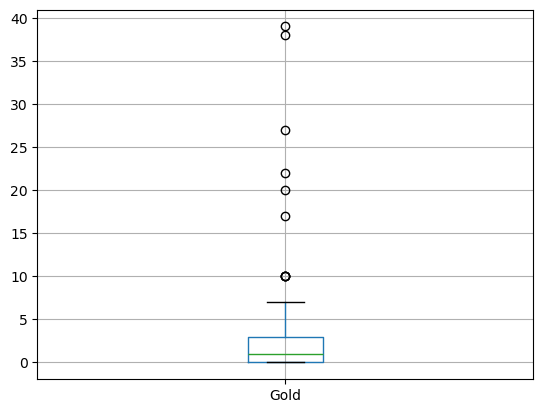

In [8]:
# Create a boxplot
# pd.DataFrame.boxplot(medal_count['Gold']) --> this also does the job
import matplotlib.pyplot as plt
medal_count.boxplot(column="Gold", by=None, ax=None)
plt.show()

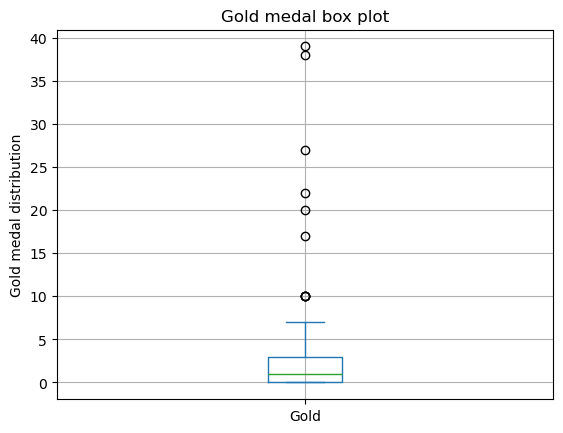

In [9]:
medal_count['Gold'].plot(kind='box',title='Gold medal box plot')
plt.ylabel("Gold medal distribution")
plt.grid() # show the grid
plt.show()

In [10]:
# Frequency tables
binnedMedals = pd.cut(medal_count['Gold'], 10) # divides interval (0.39) into 10 bins as shown below
print(binnedMedals.value_counts())
print("\n\nLets create a copy of the medal_count table and add a new column called 'Freq':\n")
new_medal_count = medal_count.copy()
new_medal_count['Freq'] = pd.cut(medal_count['Gold'], 10)

Gold
(-0.039, 3.9]    72
(3.9, 7.8]       11
(7.8, 11.7]       4
(19.5, 23.4]      2
(35.1, 39.0]      2
(15.6, 19.5]      1
(23.4, 27.3]      1
(11.7, 15.6]      0
(27.3, 31.2]      0
(31.2, 35.1]      0
Name: count, dtype: int64


Lets create a copy of the medal_count table and add a new column called 'Freq':



In [11]:
new_medal_count.groupby('Freq')['Gold'].count().reset_index()

C:\Users\adminuser\AppData\Local\Temp\ipykernel_7064\484425617.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  new_medal_count.groupby('Freq')['Gold'].count().reset_index()


,Freq,Gold
0,"(-0.039, 3.9]",72
1,"(3.9, 7.8]",11
2,"(7.8, 11.7]",4
3,"(11.7, 15.6]",0
4,"(15.6, 19.5]",1
5,"(19.5, 23.4]",2
6,"(23.4, 27.3]",1
7,"(27.3, 31.2]",0
8,"(31.2, 35.1]",0
9,"(35.1, 39.0]",2


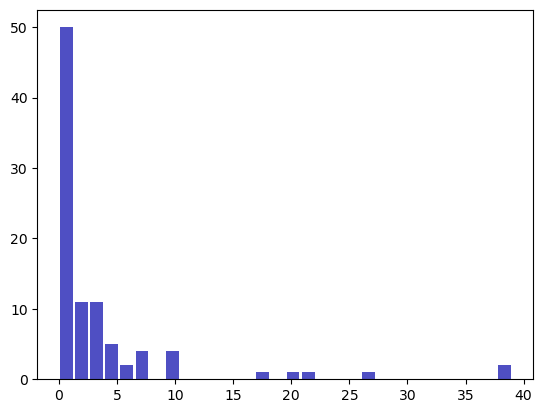

In [12]:
# Plot a histogram for medal_count['Gold']
import matplotlib.pyplot as plt
# below line from realpython-> https://realpython.com/python-histograms/
#   The o. of bins here can be set to a number of preference
plt.hist(x=medal_count['Gold'], bins='auto', color='#0504aa', alpha=0.7, rwidth=0.85)
plt.show()

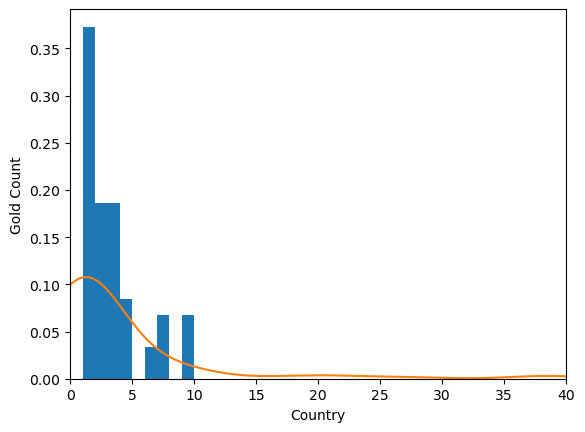

In [13]:
# Density plot -> Sort of a smooth histogram
ax = medal_count['Gold'].plot.hist(density=True, xlim=[0,40], bins=range(1,11))
medal_count['Gold'].plot.density(ax=ax)
ax.set_xlabel('Country')
ax.set_ylabel('Gold Count')
plt.show()

### Exploring binary and categorical data

In [14]:
# Mode
medal_count['Gold'].mode()

0    0
Name: Gold, dtype: int64

In [15]:
# Expected value : Sum of each value multiplied by probability of occurance

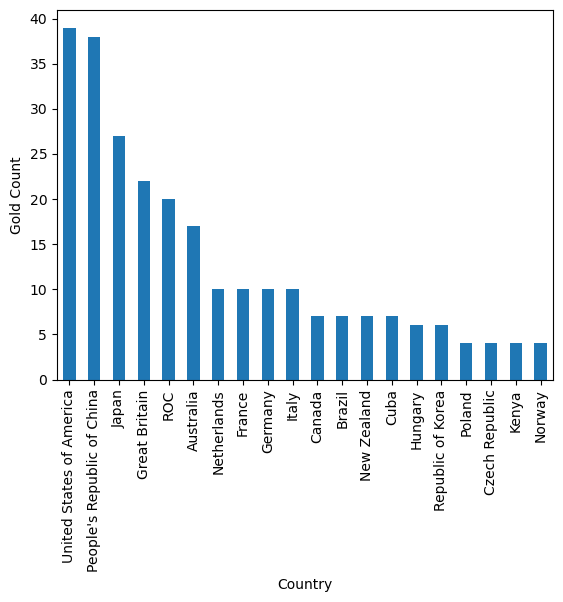

In [16]:
# Bar charts : Freq or proportion of each category plotted as bars
ax = medal_count.iloc[:20,:].plot.bar(x='Team/NOC', y='Gold', legend=False)
ax.set_xlabel('Country')
ax.set_ylabel('Gold Count')
plt.show()

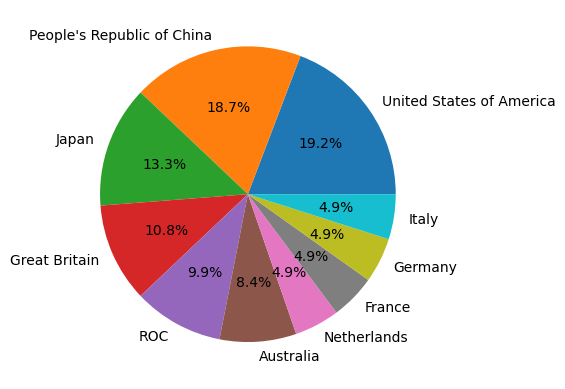

In [17]:
# Plot a pie chart
import numpy as np

y = np.array(medal_count['Gold'].iloc[:10])
mylabels = medal_count['Team/NOC'].iloc[:10]

plt.pie(y, labels = mylabels, autopct='%1.1f%%')
plt.show()
#dframe = pd.DataFrame({'Gold': medal_count['Gold']}, index=medal_count['Team/NOC'])
#dframe.plot.pie(y='Gold')
#plt.show()

### _Correlation_

In [18]:
# Generally pearson's corelation coefficient is used --> Refer personal notes
# note: medal_count here has string values and corr cannot calculate on strings,
#       hence we take from the 2nd row with acta values
medal_count.iloc[:,2:].corr()

,Gold,Silver,Bronze,Total,Rank by Total
Gold,1.000000,0.929046,0.862425,0.970840,-0.626012
Silver,0.929046,1.000000,0.862646,0.969439,-0.632831
Bronze,0.862425,0.862646,1.000000,0.941941,-0.745573
Total,0.970840,0.969439,0.941941,1.000000,-0.692450
Rank by Total,-0.626012,-0.632831,-0.745573,-0.692450,1.000000


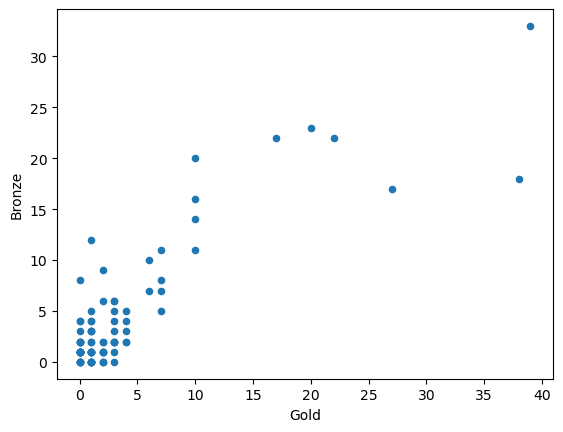

In [19]:
# Scatter plot of Gold vs Bronze
ax1 = medal_count.plot.scatter(x='Gold', y = 'Bronze')
ax1.set_xlabel('Gold')
ax1.set_ylabel('Bronze')
plt.show()

### **Exploring two or more variables**

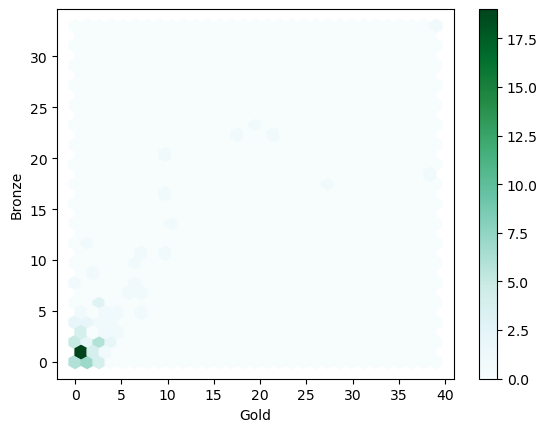

In [20]:
# Hexagonal plot 
#   It put the data into bins. 
#   gridsize determines density and resolution of hexagonal grid by setting the number of hexagons along the x-axis
#   the higher the gridsize, the smaller the hexagon
ax1 = medal_count.plot.hexbin(x='Gold', y='Bronze', gridsize=30, sharex=False)
plt.show()

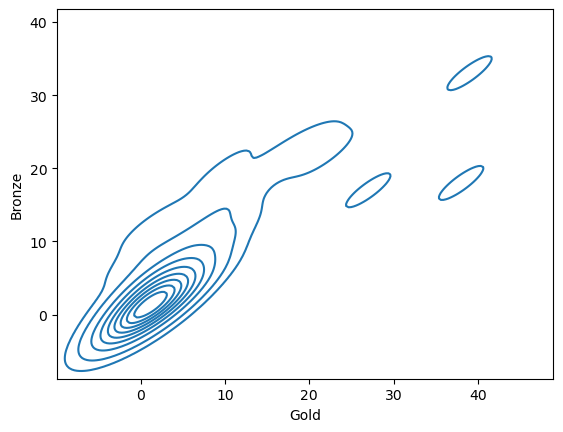

In [21]:
import seaborn as sns
ax = sns.kdeplot(x=medal_count['Gold'], y = medal_count['Bronze'])
ax.set_xlabel('Gold')
ax.set_ylabel('Bronze')
plt.show()

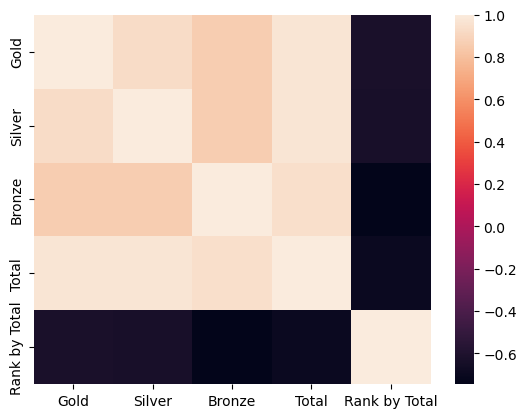

In [22]:
sns.heatmap(medal_count.iloc[:, 2:].corr())
plt.show()
# Note: Also check how to use categorical heatmaps if you want to have numbers in squares for better visibility)

In [23]:
# Pivot tables
#medal_count.pivot_table(index='Gold', columns='Bronze',  aggfunc=lambda x: len(x))
piv_tab = medal_count[['Gold','Bronze']].pivot_table(index='Gold', columns='Bronze',  aggfunc=lambda x: len(x))
piv_tab.fillna(0)
# NOTE! aggfunc calculates for the values specified in "columns", can also be:
#   aggsum = 'sum' or 'mean', ''median','min','max','count','std','var'

Bronze,0,1,2,3,4,5,6,7,8,9,...,11,12,14,16,17,18,20,22,23,33
Gold,,,,,,,,,,,,,,,,,,,,,
0,6.0,13.0,5.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,7.0,6.0,2.0,3.0,2.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,4.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,4.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


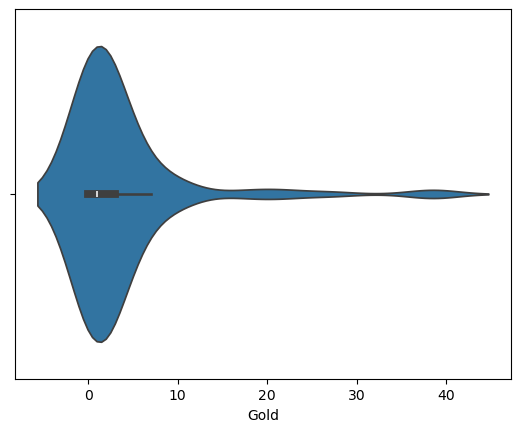

In [24]:
# Violin plot
sns.violinplot(x=medal_count['Gold'])
plt.show()